In [5]:
import pandas as pd


df = pd.read_csv('/content/final_gdp_co2_dataset.csv')


print(df.head())

  country  year  gdp_per_capita_usd  co2_emissions_per_capita_tons  \
0   China  1994          611.262012                       2.582410   
1   China  1995         1001.162108                       2.968782   
2   China  1996         1408.422417                       3.299886   
3   China  1997         1910.009994                       3.680102   
4   China  1998         2294.856545                       3.870424   

   gdp_per_capita_sq  
0       3.736412e+05  
1       1.002326e+06  
2       1.983654e+06  
3       3.648138e+06  
4       5.266367e+06  


In [7]:
import pandas as pd


df = pd.read_csv('final_gdp_co2_dataset.csv')


print(df.columns)

Index(['country', 'year', 'gdp_per_capita_usd',
       'co2_emissions_per_capita_tons', 'gdp_per_capita_sq'],
      dtype='object')


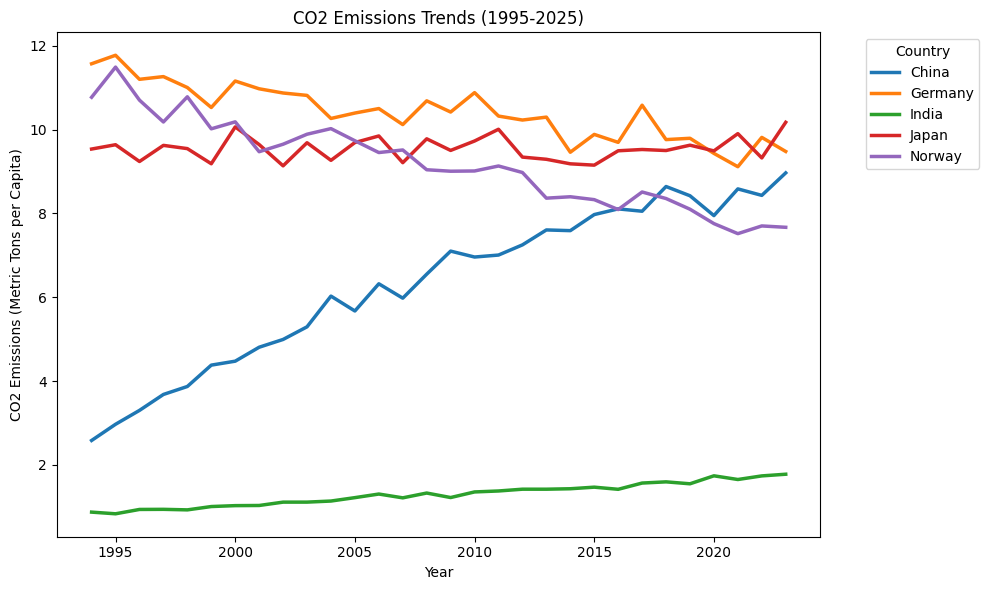

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x='year',
    y='co2_emissions_per_capita_tons',
    hue='country',
    palette='tab10',
    linewidth=2.5,
)
plt.title('CO2 Emissions Trends (1995-2025)')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (Metric Tons per Capita)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

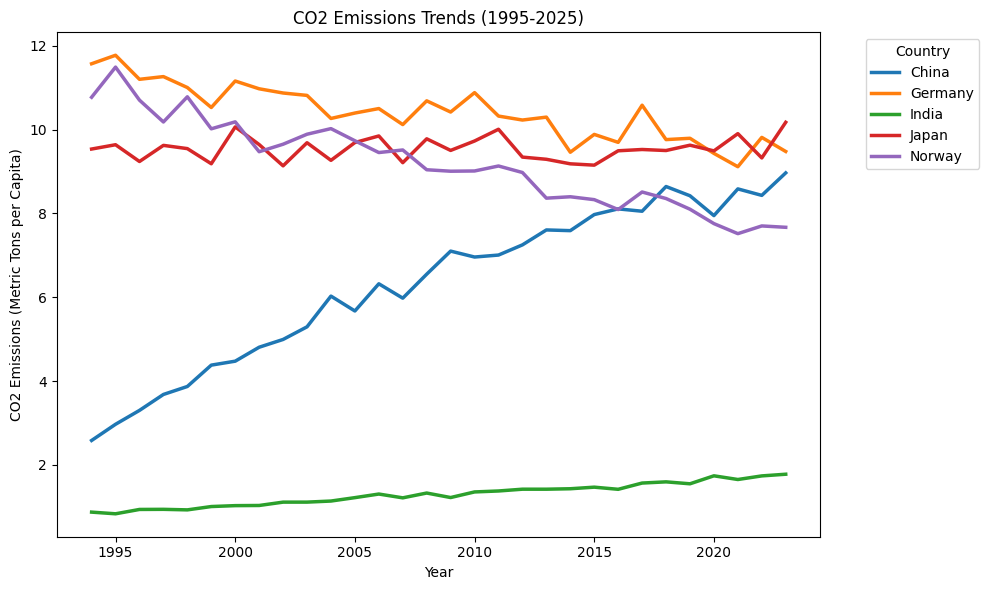

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x='year',
    y='co2_emissions_per_capita_tons',
    hue='country',
    palette='tab10',
    linewidth=2.5,
)
plt.title('CO2 Emissions Trends (1995-2025)')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (Metric Tons per Capita)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

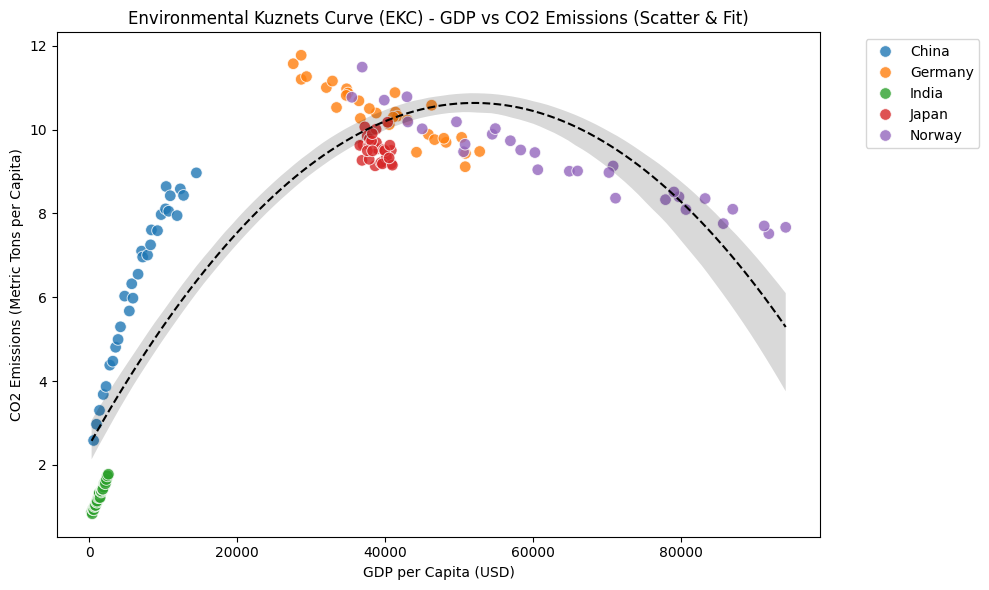

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='gdp_per_capita_usd',
    y='co2_emissions_per_capita_tons',
    hue='country',
    palette='tab10',
    alpha=0.8,
    s=70,
)

sns.regplot(
    data=df,
    x='gdp_per_capita_usd',
    y='co2_emissions_per_capita_tons',
    scatter=False,
    order=2,
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 1.5, 'label': 'EKC Inverted-U Fit'},
)

plt.title(
    'Environmental Kuznets Curve (EKC) - GDP vs CO2 Emissions (Scatter & Fit)'
)
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('CO2 Emissions (Metric Tons per Capita)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

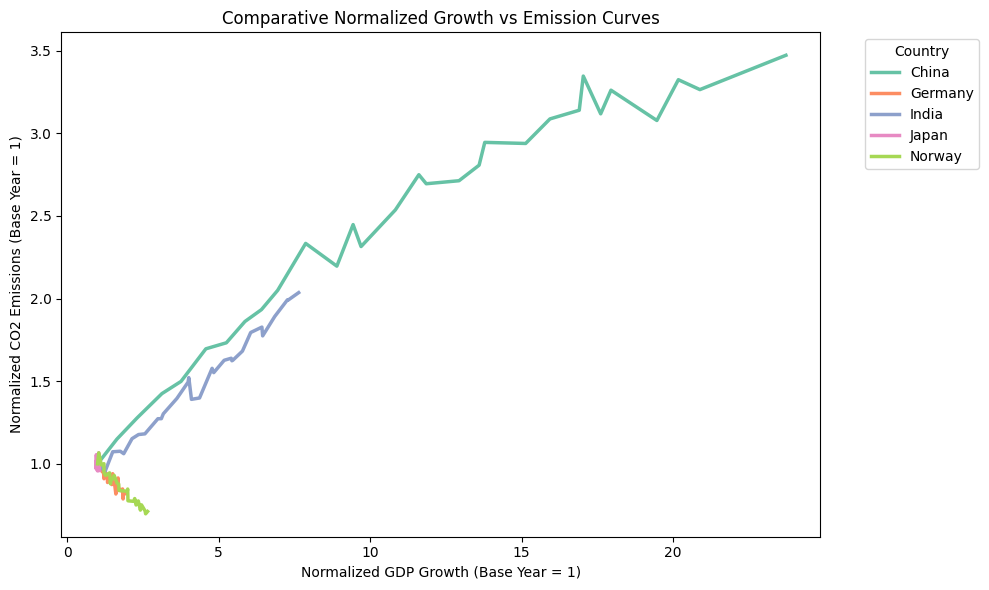

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


df['Normalized_GDP'] = df.groupby('country')['gdp_per_capita_usd'].transform(
    lambda x: x / x.iloc[0]
)
df['Normalized_CO2'] = df.groupby('country')[
    'co2_emissions_per_capita_tons'
].transform(lambda x: x / x.iloc[0])


plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x='Normalized_GDP',
    y='Normalized_CO2',
    hue='country',
    palette='Set2',
    linewidth=2.5,
)

plt.title('Comparative Normalized Growth vs Emission Curves')
plt.xlabel('Normalized GDP Growth (Base Year = 1)')
plt.ylabel('Normalized CO2 Emissions (Base Year = 1)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

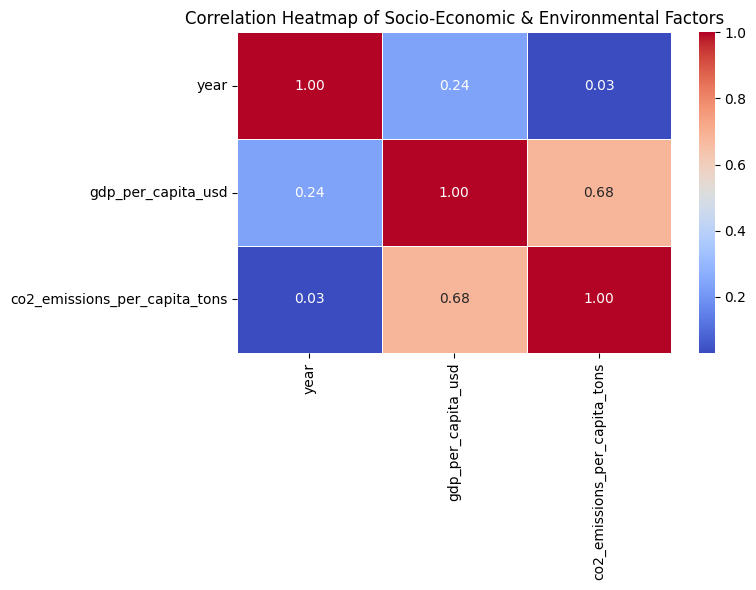

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

corr_matrix = df[
    ['year', 'gdp_per_capita_usd', 'co2_emissions_per_capita_tons']
].corr()


sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True
)

plt.title('Correlation Heatmap of Socio-Economic & Environmental Factors')
plt.tight_layout()
plt.show()

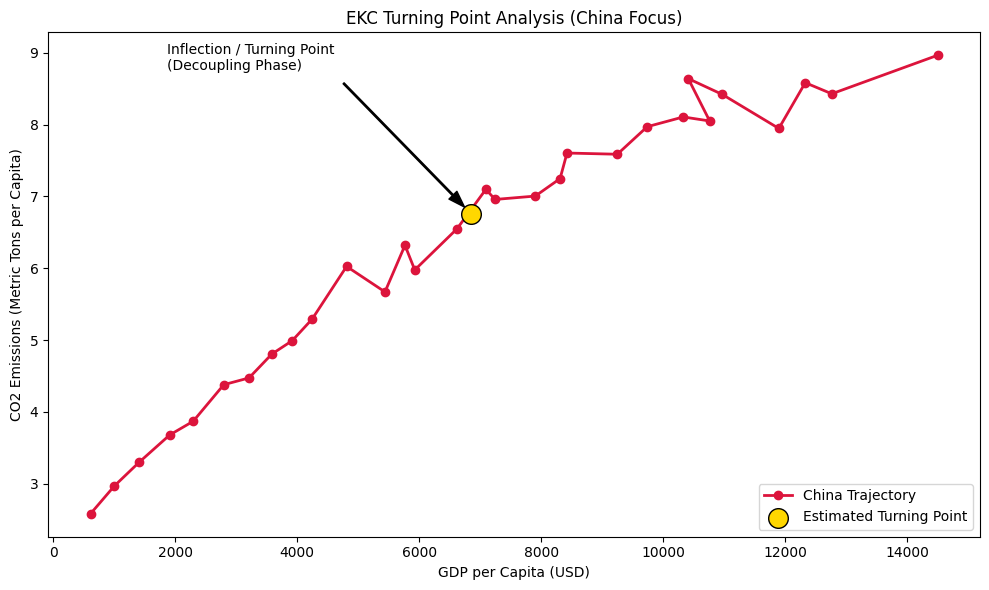

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

china_data = df[df['country'] == 'China']

plt.plot(
    china_data['gdp_per_capita_usd'],
    china_data['co2_emissions_per_capita_tons'],
    marker='o',
    color='crimson',
    linewidth=2,
    label='China Trajectory',
)


turning_gdp = china_data['gdp_per_capita_usd'].median()
turning_co2 = china_data['co2_emissions_per_capita_tons'].median()

plt.scatter(
    [turning_gdp],
    [turning_co2],
    color='gold',
    s=200,
    zorder=5,
    edgecolor='black',
    label='Estimated Turning Point',
)

plt.annotate(
    'Inflection / Turning Point\n(Decoupling Phase)',
    xy=(turning_gdp, turning_co2),
    xytext=(turning_gdp - 5000, turning_co2 + 2),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
)

plt.title('EKC Turning Point Analysis (China Focus)')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('CO2 Emissions (Metric Tons per Capita)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()